# TabTransformer + GBDT 앙상블 

In [41]:
import gc, copy
from contextlib import nullcontext
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda')


USE_AMP = (device.type == 'cuda')         
PIN = (device.type == 'cuda')          
NUM_WORKERS = 0                                
XGB_DEVICE = 'cuda' if device.type == 'cuda' else 'cpu'

print('torch', torch.__version__, '| device', device, '| AMP', USE_AMP)
if device.type == 'cuda':
    print('GPU :', torch.cuda.get_device_name(0))

torch 2.12.0+cu132 | device cuda | AMP True
GPU : NVIDIA GeForce RTX 5060 Ti


In [42]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 실험 설정 코드

In [43]:
EXPERIMENT_CONFIG = {
    'experiment_name' : 'exp04',
    'n_layers'        : 5,
    'n_heads'         : 4,
    'dim_feedforward' : 512,
    'dropout'         : 0.15,
    'n_epochs'        : 100,
    'patience'        : 12,
    'batch_size'      : 4096,
    'lr'              : 2e-4,
    'weight_decay'    : 1e-4,
    'warmup_epochs'   : 5,
    'grad_clip'       : 1.0,
}
print(f"실험: {EXPERIMENT_CONFIG['experiment_name']}")
for k, v in EXPERIMENT_CONFIG.items():
    if k != 'experiment_name':
        print(f"  {k:<18}: {v}")

실험: exp04
  n_layers          : 5
  n_heads           : 4
  dim_feedforward   : 512
  dropout           : 0.15
  n_epochs          : 100
  patience          : 12
  batch_size        : 4096
  lr                : 0.0002
  weight_decay      : 0.0001
  warmup_epochs     : 5
  grad_clip         : 1.0


## 1. 데이터 로딩 & 전처리


In [44]:
data_path = './data/kaggle_data/'
train = pd.read_csv(data_path + 'train.csv')
test  = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')
print('Train', train.shape, '| Test', test.shape)

#feature 나누기

#Transformer에 입력할 Feature
cat_features  = ['Compound', 'Race', 'Stint', 'Year']

#TabTransformer 에서 단순 mlp로 처리할 피처
cont_features = ['LapNumber', 'TyreLife', 'Position',
                 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
                 'RaceProgress', 'Position_Change', 'PitStop']

#타겟값
target = 'PitNextLap'

#임베딩 차원 설정 -> 고유값 개수별로 GPT에 맡겨서 임의 설정
emb_dim_map = {'Compound': 8, 'Race': 16, 'Stint': 8, 'Year': 4}


#Train Test 합치기
all_data = pd.concat([train, test], ignore_index=True)
cat_dims, cat_emb_dims = [], []

#cat_features 라벨인코딩
for col in cat_features:
    le = LabelEncoder()
    all_data[col + '_enc'] = le.fit_transform(all_data[col].astype(str))
    cat_dims.append(len(le.classes_))
    cat_emb_dims.append(emb_dim_map[col])

# Train, Test 분리
cat_enc_cols = [c + '_enc' for c in cat_features]
train_df = all_data.iloc[:len(train)].copy()
test_df  = all_data.iloc[len(train):].copy().reset_index(drop=True)

#타겟값 추출
y = train[target].values.astype(np.float32)

#레이스_연도 그룹 생성
groups = (train['Race'].astype(str) + '_' + train['Year'].astype(str)).values

#1 타겟값에 가중치 설정
pos_rate = y.mean()
spw = (1 - pos_rate) / pos_rate


print('cat_dims', dict(zip(cat_features, cat_dims)))
print('emb_dims', dict(zip(cat_features, cat_emb_dims)))
print('d_model (max emb_dim):', max(cat_emb_dims))
print('pos rate', round(float(pos_rate), 4), '| scale_pos_weight', round(spw, 3))
print('groups (Race+Year) 수:', len(np.unique(groups)))

Train (439140, 16) | Test (188165, 15)
cat_dims {'Compound': 5, 'Race': 26, 'Stint': 8, 'Year': 4}
emb_dims {'Compound': 8, 'Race': 16, 'Stint': 8, 'Year': 4}
d_model (max emb_dim): 16
pos rate 0.199 | scale_pos_weight 4.026
groups (Race+Year) 수: 104


## 2. TabTransformer & Dataset 정의

In [45]:
class TabTransformer(nn.Module):
    def __init__(self, cat_dims, cat_emb_dims, n_continuous):
        cfg = EXPERIMENT_CONFIG
        n_heads = cfg['n_heads']
        n_layers = cfg['n_layers']
        dim_feedforward= cfg['dim_feedforward']
        dropout = cfg['dropout']
        
        super().__init__()

        #범주형 임베딩 생성
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, emb_dim) for n_cats, emb_dim in zip(cat_dims, cat_emb_dims)])
        
        #임베딩 차원 통일
        self.emb_dim = max(cat_emb_dims)
        self.projections = nn.ModuleList([
            nn.Linear(d, self.emb_dim) if d != self.emb_dim else nn.Identity()
            for d in cat_emb_dims])
        
        #트랜스포머 레이어 생성
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.emb_dim, nhead=n_heads, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        #최종 예측용 MLP
        total_dim = self.emb_dim * len(cat_dims) + n_continuous
        self.classifier = nn.Sequential(
            nn.LayerNorm(total_dim), 
            nn.Dropout(dropout),
            nn.Linear(total_dim, 256), 
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 64),  nn.GELU(), 
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1))

    #MLP용 벡터 생성
    def get_embeddings(self, cat_x, cont_x):
        embs = [proj(emb(cat_x[:, i]))
                for i, (emb, proj) in enumerate(zip(self.embeddings, self.projections))]
        emb_seq = torch.stack(embs, dim=1)
        emb_seq = self.transformer(emb_seq)
        emb_flat = emb_seq.flatten(1)
        return torch.cat([emb_flat, cont_x], dim=1)

    def forward(self, cat_x, cont_x):
        return self.classifier(self.get_embeddings(cat_x, cont_x)).squeeze(-1)


class TabDataset(Dataset):
    def __init__(self, df, cat_cols, cont_cols, labels=None):
        self.cat  = torch.LongTensor(df[cat_cols].values)
        self.cont = torch.FloatTensor(df[cont_cols].values)
        self.labels = torch.FloatTensor(labels) if labels is not None else None
    def __len__(self):
        return len(self.cat)
    def __getitem__(self, i):
        if self.labels is not None:
            return self.cat[i], self.cont[i], self.labels[i]
        return self.cat[i], self.cont[i]

EMB_OUT = max(cat_emb_dims) * len(cat_dims) + len(cont_features)
print('임베딩 출력 차원:', EMB_OUT)

임베딩 출력 차원: 73


## 3. 학습 및 추론 유틸 


In [46]:
#AMP 관리
def amp_ctx():
    return torch.autocast(device_type='cuda', enabled=True) if USE_AMP else nullcontext()

#데이터 로더 배치 단위 처리
def _loader(df, cat_cols, cont_cols, labels=None, bs=4096, shuffle=False):
    return DataLoader(TabDataset(df, cat_cols, cont_cols, labels),
                      batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=PIN)

# 추론용 모델
def predict_tt(model, df, cat_cols, cont_cols, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for cats, conts in _loader(df, cat_cols, cont_cols, bs=bs):
            cats = cats.to(device, non_blocking=True); conts = conts.to(device, non_blocking=True)
            with amp_ctx():
                logit = model(cats, conts)
            out.append(torch.sigmoid(logit.float()).cpu().numpy())
    return np.concatenate(out)

#앙상블용 임베딩 추출
def extract_embeddings(model, df, cat_cols, cont_cols, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for cats, conts in _loader(df, cat_cols, cont_cols, bs=bs):
            cats = cats.to(device, non_blocking=True); conts = conts.to(device, non_blocking=True)
            with amp_ctx():
                e = model.get_embeddings(cats, conts)
            out.append(e.float().cpu().numpy())
    return np.vstack(out)

#트랜스포머 훈련
def train_tabtransformer(tr_df, va_df, y_tr, y_va, cat_cols, cont_cols, verbose=False):
    cfg = EXPERIMENT_CONFIG
    n_epochs, patience = cfg['n_epochs'], cfg['patience']
    batch_size, lr = cfg['batch_size'], cfg['lr']
    warmup_ep, grad_clip = cfg['warmup_epochs'], cfg['grad_clip']

    model = TabTransformer(cat_dims, cat_emb_dims, len(cont_cols)).to(device)
    
    #pos_weight 적용
    pw = torch.tensor([(1 - y_tr.mean()) / y_tr.mean()], dtype=torch.float32, device=device)

    #Loss 함수
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    #옵티마이저
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=cfg['weight_decay'])

    #scheduler
    warmup_sched = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_ep)
    cosine_sched = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(n_epochs - warmup_ep, 1))
    scheduler = optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[warmup_ep])
    
    scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    
    tr_loader = _loader(tr_df, cat_cols, cont_cols, y_tr, bs=batch_size, shuffle=True)
    
    best_auc, best_state, no_improve = 0.0, None, 0
    
    epochs_done = 0
    
    for epoch in range(n_epochs):
        epochs_done = epoch + 1
        #train 모드
        model.train()


        for cats, conts, labels in tr_loader:
            #GPU로 데이터 이동
            cats   = cats.to(device, non_blocking=True)
            conts  = conts.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            #Gradient 초기화
            optimizer.zero_grad()
            
            #Loss 계산 AMP로 처리 
            with amp_ctx():
                loss = criterion(model(cats, conts), labels)

            #역전파    
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)


            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            scaler_amp.step(optimizer)
            scaler_amp.update()
        scheduler.step()

        #AUC 측정
        auc = roc_auc_score(y_va, predict_tt(model, va_df, cat_cols, cont_cols))
        if verbose:
            print(f'    epoch {epoch+1:02d} | val AUC {auc:.4f}')

        #Early Stopping
        if auc > best_auc:
            best_auc, best_state, no_improve = auc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_auc, epochs_done

## 4. per-fold OOF 

In [47]:
import time

#GroupKFold
gkf = GroupKFold(n_splits=5)

#레이스_시즌 단위로 group화 한걸 GroupKFold
splits = list(gkf.split(train_df, y, groups=groups))   

#oof 저장요 배열 생성
oof_tt  = np.zeros(len(train_df))
oof_lgb = np.zeros(len(train_df))
oof_xgb = np.zeros(len(train_df))


tt_test_folds, lgb_test_folds, xgb_test_folds = [], [], []
fold_log = []
fold_times = []   

lgb_params = {'objective': 'binary', 'metric': 'auc', 'learning_rate': 0.05,
              'num_leaves': 127, 'max_depth': -1, 'min_child_samples': 50,
              'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
              'scale_pos_weight': spw, 'n_jobs': -1, 'verbose': -1, 'random_state': SEED}
xgb_params = {'objective': 'binary:logistic', 'eval_metric': 'auc', 'learning_rate': 0.05,
              'max_depth': 6, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'scale_pos_weight': spw, 'tree_method': 'hist', 'device': XGB_DEVICE,
              'random_state': SEED, 'verbosity': 0}

#시간 측정
t0 = time.time()

# Fold별 반복
for f, (tr, va) in enumerate(splits):

    #측정 초기화
    print(f'===== Fold {f} =====')
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()

    #변수 스케일링 train fit -> va, te
    sc = StandardScaler().fit(train_df.iloc[tr][cont_features])
    
    tr_df = train_df.iloc[tr].copy(); tr_df[cont_features] = sc.transform(tr_df[cont_features])
    va_df = train_df.iloc[va].copy(); va_df[cont_features] = sc.transform(va_df[cont_features])
    te_df = test_df.copy(); te_df[cont_features] = sc.transform(te_df[cont_features])


    t_tt = time.time()

    #Transformer 학습
    model, tt_auc, ep_done = train_tabtransformer(tr_df, va_df, y[tr], y[va], cat_enc_cols, cont_features)
    tt_time = time.time() - t_tt
    torch.save(model.state_dict(), f'best_tabtransformer_fold{f}.pth')
    peak_mem_mb = torch.cuda.max_memory_allocated() / 1e6 if device.type == 'cuda' else 0.0

    #예측
    oof_tt[va] = predict_tt(model, va_df, cat_enc_cols, cont_features)
    tt_test_folds.append(predict_tt(model, te_df, cat_enc_cols, cont_features))


    #임베딩 추출
    emb_tr = extract_embeddings(model, tr_df, cat_enc_cols, cont_features)
    emb_va = extract_embeddings(model, va_df, cat_enc_cols, cont_features)
    emb_te = extract_embeddings(model, te_df, cat_enc_cols, cont_features)

    #lightGBM 학습
    t_lgb = time.time()
    dtr = lgb.Dataset(emb_tr, label=y[tr]); dva = lgb.Dataset(emb_va, label=y[va])
    lgbm = lgb.train(lgb_params, dtr, num_boost_round=1000, valid_sets=[dva],
                     callbacks=[lgb.early_stopping(50, verbose=False)])
    
    #lightGBM 예측
    oof_lgb[va] = lgbm.predict(emb_va)
    lgb_test_folds.append(lgbm.predict(emb_te))
    lgb_auc = roc_auc_score(y[va], oof_lgb[va])
    lgb_time = time.time() - t_lgb

    #XGboost 학습
    t_xgb = time.time()
    dxt = xgb.DMatrix(emb_tr, label=y[tr]); dxv = xgb.DMatrix(emb_va, label=y[va])
    xgbm = xgb.train(xgb_params, dxt, num_boost_round=1000, evals=[(dxv, 'val')],
                     early_stopping_rounds=50, verbose_eval=False)
    
    #XGboost 예측
    oof_xgb[va] = xgbm.predict(dxv)
    xgb_test_folds.append(xgbm.predict(xgb.DMatrix(emb_te)))
    xgb_auc = roc_auc_score(y[va], oof_xgb[va])
    xgb_time = time.time() - t_xgb

    #결과 정리
    print(f'  AUC : TT {tt_auc:.4f} | LGBM {lgb_auc:.4f} | XGB {xgb_auc:.4f}')
    print(f'  시간: TT {tt_time:.0f}s ({ep_done}ep) | LGBM {lgb_time:.0f}s | XGB {xgb_time:.0f}s'
          + (f' | GPU peak {peak_mem_mb:.0f}MB' if device.type == 'cuda' else ''))
    fold_log.append({'fold': f, 'tt': tt_auc, 'lgb': lgb_auc, 'xgb': xgb_auc})
    fold_times.append({'fold': f,
                       'tt_s': round(tt_time, 1), 'lgb_s': round(lgb_time, 1), 'xgb_s': round(xgb_time, 1),
                       'ep': ep_done, 'gpu_peak_mb': round(peak_mem_mb, 0)})
    del model, emb_tr, emb_va, emb_te
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

total_elapsed = time.time() - t0
print(f'\nOOF AUC  TT {roc_auc_score(y, oof_tt):.4f} | LGBM {roc_auc_score(y, oof_lgb):.4f} | XGB {roc_auc_score(y, oof_xgb):.4f}')
ft = pd.DataFrame(fold_times)
print(f'총 학습 시간: {total_elapsed:.0f}s ({total_elapsed/60:.1f}분)')
print(f'  TT 합계  {ft.tt_s.sum():.0f}s | LGBM 합계 {ft.lgb_s.sum():.0f}s | XGB 합계 {ft.xgb_s.sum():.0f}s')
print(ft[['fold', 'tt_s', 'lgb_s', 'xgb_s', 'ep', 'gpu_peak_mb']].to_string(index=False))

===== Fold 0 =====
  AUC : TT 0.9082 | LGBM 0.9303 | XGB 0.9301
  시간: TT 263s (49ep) | LGBM 10s | XGB 6s | GPU peak 346MB
===== Fold 1 =====
  AUC : TT 0.9127 | LGBM 0.9285 | XGB 0.9301
  시간: TT 307s (58ep) | LGBM 5s | XGB 4s | GPU peak 346MB
===== Fold 2 =====
  AUC : TT 0.9202 | LGBM 0.9412 | XGB 0.9407
  시간: TT 323s (60ep) | LGBM 10s | XGB 6s | GPU peak 346MB
===== Fold 3 =====
  AUC : TT 0.9069 | LGBM 0.9258 | XGB 0.9243
  시간: TT 125s (22ep) | LGBM 11s | XGB 3s | GPU peak 346MB
===== Fold 4 =====
  AUC : TT 0.8864 | LGBM 0.9121 | XGB 0.9128
  시간: TT 103s (19ep) | LGBM 5s | XGB 3s | GPU peak 346MB

OOF AUC  TT 0.9080 | LGBM 0.9282 | XGB 0.9279
총 학습 시간: 1217s (20.3분)
  TT 합계  1122s | LGBM 합계 42s | XGB 합계 21s
 fold  tt_s  lgb_s  xgb_s  ep  gpu_peak_mb
    0 262.8   10.4    5.5  49        346.0
    1 307.4    5.1    3.7  58        346.0
    2 322.9   10.0    5.8  60        346.0
    3 125.4   10.8    2.6  22        346.0
    4 103.3    5.3    3.1  19        346.0


## 5. 앙상블 최적화

In [48]:
# 단인 모델 OOF_AUC
auc_tt  = roc_auc_score(y, oof_tt)
auc_lgb = roc_auc_score(y, oof_lgb)
auc_xgb = roc_auc_score(y, oof_xgb)

#모델간 상관관계
oof_df = pd.DataFrame({'tt': oof_tt, 'lgb': oof_lgb, 'xgb': oof_xgb})
print('OOF correlation:'); print(oof_df.corr().round(4))

# 등가중 앙상블
ens_equal = (oof_tt + oof_lgb + oof_xgb) / 3
auc_equal = roc_auc_score(y, ens_equal)

# GBDT만 등가중 앙상블
auc_gbdt = roc_auc_score(y, (oof_lgb + oof_xgb) / 2)

# 가중 최적화 앙상블
best_w, best_auc_w = None, -1
for w1 in np.arange(0, 1.0001, 0.05):
    for w2 in np.arange(0, 1.0001 - w1, 0.05):
        w3 = 1 - w1 - w2
        a = roc_auc_score(y, w1 * oof_tt + w2 * oof_lgb + w3 * oof_xgb)
        if a > best_auc_w:
            best_auc_w, best_w = a, (round(w1, 2), round(w2, 2), round(w3, 2))

oof_best = best_w[0] * oof_tt + best_w[1] * oof_lgb + best_w[2] * oof_xgb
gain = best_auc_w - max(auc_tt, auc_lgb, auc_xgb)
print(f'\n등가중 AUC {auc_equal:.4f} | GBDT앙상블 {auc_gbdt:.4f}')
print(f'가중최적 AUC {best_auc_w:.4f} | weights (tt,lgb,xgb)={best_w}')


OOF correlation:
         tt     lgb     xgb
tt   1.0000  0.9356  0.9426
lgb  0.9356  1.0000  0.9903
xgb  0.9426  0.9903  1.0000

등가중 AUC 0.9265 | GBDT앙상블 0.9288
가중최적 AUC 0.9288 | weights (tt,lgb,xgb)=(np.float64(0.0), np.float64(0.55), np.float64(0.45))


# 로그 저장

In [49]:
import os

_log_path = './experiment_log.csv'
_ft = pd.DataFrame(fold_times) if 'fold_times' in vars() and fold_times else pd.DataFrame()
_row = {
    'experiment_name' : EXPERIMENT_CONFIG['experiment_name'],
    'n_layers'        : EXPERIMENT_CONFIG['n_layers'],
    'n_heads'         : EXPERIMENT_CONFIG['n_heads'],
    'dim_feedforward' : EXPERIMENT_CONFIG['dim_feedforward'],
    'dropout'         : EXPERIMENT_CONFIG['dropout'],
    'n_epochs'        : EXPERIMENT_CONFIG['n_epochs'],
    'patience'        : EXPERIMENT_CONFIG['patience'],
    'lr'              : EXPERIMENT_CONFIG['lr'],
    'warmup_epochs'   : EXPERIMENT_CONFIG['warmup_epochs'],
    'grad_clip'       : EXPERIMENT_CONFIG['grad_clip'],
    'oof_tt'          : round(float(auc_tt),  4),
    'oof_lgb'         : round(float(auc_lgb), 4),
    'oof_xgb'         : round(float(auc_xgb), 4),
    'oof_ensemble'    : round(float(best_auc_w), 4),
    'best_w_tt'       : float(best_w[0]),
    'best_w_lgb'      : float(best_w[1]),
    'best_w_xgb'      : float(best_w[2]),
    'emb_gain'        : round(float(auc_lgb - auc_raw), 4) if 'auc_raw' in vars() else None,
    'elapsed_s'       : round(total_elapsed, 1),
    'tt_total_s'      : round(float(_ft['tt_s'].sum()), 1)  if not _ft.empty else None,
    'lgb_total_s'     : round(float(_ft['lgb_s'].sum()), 1) if not _ft.empty else None,
    'xgb_total_s'     : round(float(_ft['xgb_s'].sum()), 1) if not _ft.empty else None,
    'avg_ep'          : round(float(_ft['ep'].mean()), 1)   if not _ft.empty else None,
    'gpu_peak_mb'     : round(float(_ft['gpu_peak_mb'].max()), 0) if not _ft.empty else None,
}
_new = pd.DataFrame([_row])
if os.path.exists(_log_path):
    _existing = pd.read_csv(_log_path)
    _existing = _existing[_existing['experiment_name'] != EXPERIMENT_CONFIG['experiment_name']]
    _new = pd.concat([_existing, _new], ignore_index=True)
_new.to_csv(_log_path, index=False)

print(f"실험 로그 저장 → {_log_path}")
print(_new[['experiment_name', 'n_layers', 'dim_feedforward', 'lr',
            'oof_tt', 'oof_lgb', 'oof_ensemble',
            'elapsed_s', 'tt_total_s', 'gpu_peak_mb']].to_string(index=False))

실험 로그 저장 → ./experiment_log.csv
experiment_name  n_layers  dim_feedforward     lr  oof_tt  oof_lgb  oof_ensemble  elapsed_s  tt_total_s  gpu_peak_mb
          exp01       3.0            512.0 0.0002  0.7733   0.9273        0.9277      776.6       696.7        439.0
          exp02       5.0            512.0 0.0002  0.8341   0.9207        0.9215     1734.9      1655.7        528.0
          exp03       3.0            512.0 0.0002  0.9076   0.9277        0.9286      860.2       768.4        242.0
            NaN       NaN              NaN    NaN     NaN      NaN           NaN        NaN         NaN          NaN
          exp05       5.0            512.0 0.0002  0.9078   0.9291        0.9296      964.9       875.6        346.0
          exp04       5.0            512.0 0.0002  0.9080   0.9282        0.9288     1217.4      1121.8        346.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

log = pd.read_csv('./experiment_log.csv').dropna(subset=['experiment_name'])
exps = log['experiment_name'].tolist()
x = np.arange(len(exps))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('실험별 성능 · 시간 · 메모리 비교', fontsize=14, fontweight='bold')

# ── 그래프 1: OOF AUC (TT 단독) ──
ax = axes[0]
bars = ax.bar(x, log['oof_tt'], color=colors[:len(exps)], width=0.5, edgecolor='white')
for bar, val in zip(bars, log['oof_tt']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(exps, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.70, 0.95)
ax.set_ylabel('OOF AUC')
ax.set_title('TabTransformer 단독 AUC')
ax.axhline(log['oof_tt'].max(), color='red', linestyle='--', linewidth=1, alpha=0.6,
           label=f'최고 {log["oof_tt"].max():.4f}')
ax.legend(fontsize=8)

# ── 그래프 2: 학습 시간 누적 막대 ──
ax = axes[1]
b1 = ax.bar(x, log['tt_total_s'],  label='TabTransformer', color='#4C72B0', width=0.5)
b2 = ax.bar(x, log['lgb_total_s'], label='LightGBM',       color='#DD8452', width=0.5,
            bottom=log['tt_total_s'])
b3 = ax.bar(x, log['xgb_total_s'], label='XGBoost',        color='#55A868', width=0.5,
            bottom=log['tt_total_s'] + log['lgb_total_s'])
for i, total in enumerate(log['elapsed_s']):
    ax.text(i, total + 15, f'{total:.0f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(exps, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('학습 시간 (초)')
ax.set_title('모델별 학습 시간 (누적)')
ax.legend(fontsize=8, loc='upper left')

# ── 그래프 3: GPU Peak Memory ──
ax = axes[2]
bars = ax.bar(x, log['gpu_peak_mb'], color=colors[:len(exps)], width=0.5, edgecolor='white')
for bar, val in zip(bars, log['gpu_peak_mb']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}MB', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(exps, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('GPU 메모리 (MB)')
ax.set_title('GPU Peak Memory')
ax.axhline(log['gpu_peak_mb'].min(), color='green', linestyle='--', linewidth=1, alpha=0.6,
           label=f'최소 {log["gpu_peak_mb"].min():.0f}MB')
ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs('./docs', exist_ok=True)
plt.savefig('./docs/experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: docs/experiment_comparison.png')

## 6. Ablation — raw 피처 vs TT 임베딩


In [50]:
raw_cols = cont_features + cat_enc_cols
X_raw = train_df[raw_cols].values

# LightGBM raw
oof_lgb_raw = np.zeros(len(train_df))
for tr, va in splits:
    dtr = lgb.Dataset(X_raw[tr], label=y[tr]); dva = lgb.Dataset(X_raw[va], label=y[va])
    m = lgb.train(lgb_params, dtr, num_boost_round=1000, valid_sets=[dva],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb_raw[va] = m.predict(X_raw[va])

# XGBoost raw
oof_xgb_raw = np.zeros(len(train_df))
for tr, va in splits:
    dxt = xgb.DMatrix(X_raw[tr], label=y[tr]); dxv = xgb.DMatrix(X_raw[va], label=y[va])
    m = xgb.train(xgb_params, dxt, num_boost_round=1000, evals=[(dxv, 'val')],
                  early_stopping_rounds=50, verbose_eval=False)
    oof_xgb_raw[va] = m.predict(dxv)

auc_raw     = roc_auc_score(y, oof_lgb_raw)
auc_xgb_raw = roc_auc_score(y, oof_xgb_raw)

print(f'raw 피처 + LGBM      OOF AUC : {auc_raw:.4f}')
print(f'TT 임베딩 + LGBM     OOF AUC : {auc_lgb:.4f}')
print(f'임베딩 효용 LGBM             : {auc_lgb - auc_raw:+.4f}')
print()
print(f'raw 피처 + XGBoost   OOF AUC : {auc_xgb_raw:.4f}')
print(f'TT 임베딩 + XGBoost  OOF AUC : {auc_xgb:.4f}')
print(f'임베딩 효용 XGBoost          : {auc_xgb - auc_xgb_raw:+.4f}')

raw 피처 + LGBM      OOF AUC : 0.9320
TT 임베딩 + LGBM     OOF AUC : 0.9282
임베딩 효용 LGBM             : -0.0038

raw 피처 + XGBoost   OOF AUC : 0.9323
TT 임베딩 + XGBoost  OOF AUC : 0.9279
임베딩 효용 XGBoost          : -0.0044


## 7. 결과 표 & 시각화

               모델  OOF_AUC       F1
TabTransformer 단독 0.907979 0.661615
   LightGBM (임베딩) 0.928200 0.707337
    XGBoost (임베딩) 0.927944 0.703394
         GBDT 앙상블 0.928787 0.706549
     전체 앙상블 (등가중) 0.926509 0.699783
    전체 앙상블 (가중최적) 0.928792 0.706662

raw+LGBM 0.9320 | 임베딩 효용 -0.0038 | 가중 (np.float64(0.0), np.float64(0.55), np.float64(0.45)) | gain +0.0006


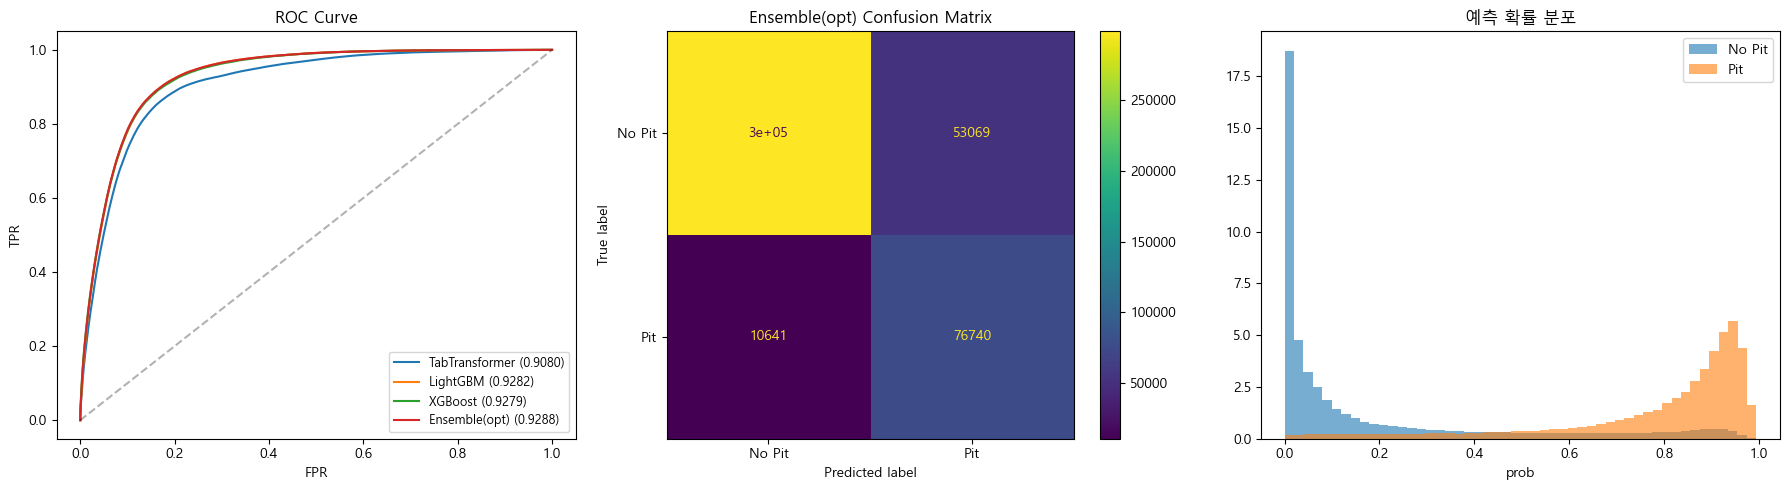

In [51]:
def f1_at(p):
    return f1_score(y, (p > 0.5).astype(int))

rows = [
    ('TabTransformer 단독', auc_tt,  f1_at(oof_tt)),
    ('LightGBM (임베딩)',   auc_lgb, f1_at(oof_lgb)),
    ('XGBoost (임베딩)',    auc_xgb, f1_at(oof_xgb)),
    ('GBDT 앙상블',         auc_gbdt, f1_at((oof_lgb + oof_xgb) / 2)),
    ('전체 앙상블 (등가중)', auc_equal, f1_at(ens_equal)),
    ('전체 앙상블 (가중최적)', best_auc_w, f1_at(oof_best)),
]
res = pd.DataFrame(rows, columns=['모델', 'OOF_AUC', 'F1'])
print(res.to_string(index=False))
print(f'\nraw+LGBM {auc_raw:.4f} | 임베딩 효용 {auc_lgb - auc_raw:+.4f} | 가중 {best_w} | gain {gain:+.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, p in [('TabTransformer', oof_tt), ('LightGBM', oof_lgb),
                ('XGBoost', oof_xgb), ('Ensemble(opt)', oof_best)]:
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y, p):.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=9)

ConfusionMatrixDisplay.from_predictions(
    y, (oof_best > 0.5).astype(int), display_labels=['No Pit', 'Pit'], ax=axes[1])
axes[1].set_title('Ensemble(opt) Confusion Matrix')

axes[2].hist(oof_best[y == 0], bins=50, alpha=0.6, label='No Pit', density=True)
axes[2].hist(oof_best[y == 1], bins=50, alpha=0.6, label='Pit', density=True)
axes[2].set_title('예측 확률 분포'); axes[2].set_xlabel('prob'); axes[2].legend()
plt.tight_layout(); plt.show()

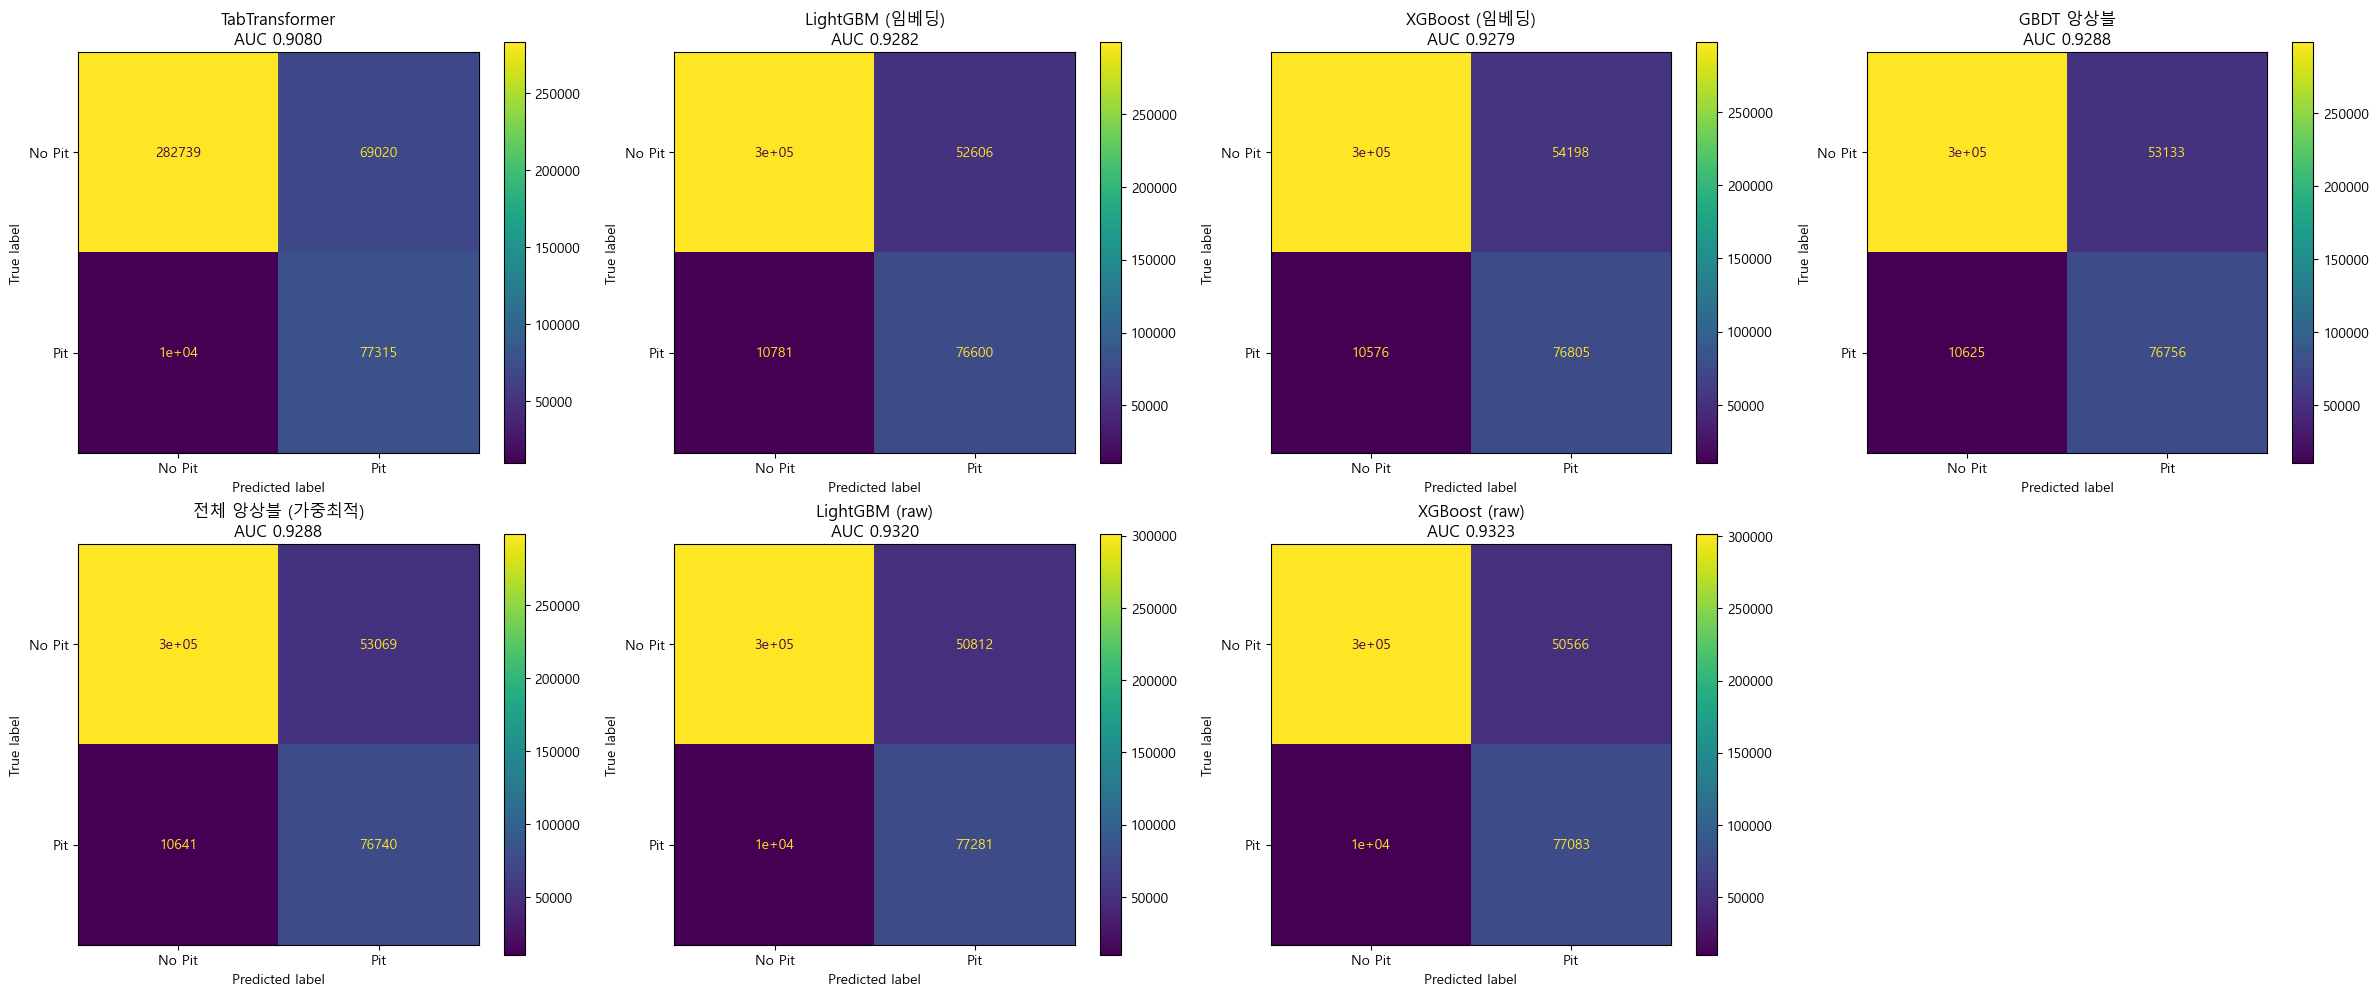

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

cms = [
    ('TabTransformer',          oof_tt),
    ('LightGBM (임베딩)',        oof_lgb),
    ('XGBoost (임베딩)',         oof_xgb),
    ('GBDT 앙상블',              (oof_lgb + oof_xgb) / 2),
    ('전체 앙상블 (가중최적)',    oof_best),
    ('LightGBM (raw)',           oof_lgb_raw),
    ('XGBoost (raw)',            oof_xgb_raw),
]

for ax, (name, p) in zip(axes.flat, cms):
    auc = roc_auc_score(y, p)
    ConfusionMatrixDisplay.from_predictions(
        y, (p > 0.5).astype(int), display_labels=['No Pit', 'Pit'], ax=ax)
    ax.set_title(f'{name}\nAUC {auc:.4f}')

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Test 추론 & 제출 (Step 9)

fold별 test 예측을 평균(fold bagging)한 뒤 최적 가중치로 Soft Voting.

In [53]:
tt_test  = np.mean(tt_test_folds, axis=0)
lgb_test = np.mean(lgb_test_folds, axis=0)
xgb_test = np.mean(xgb_test_folds, axis=0)

final = best_w[0] * tt_test + best_w[1] * lgb_test + best_w[2] * xgb_test
submission['PitNextLap'] = final
submission.to_csv('submission_tabtransformer_ensemble.csv', index=False)
print('saved submission_tabtransformer_ensemble.csv', submission.shape)
print(submission['PitNextLap'].describe())

saved submission_tabtransformer_ensemble.csv (188165, 2)
count    188165.000000
mean          0.295222
std           0.355630
min           0.000315
25%           0.010928
50%           0.084444
75%           0.639275
max           0.992424
Name: PitNextLap, dtype: float64


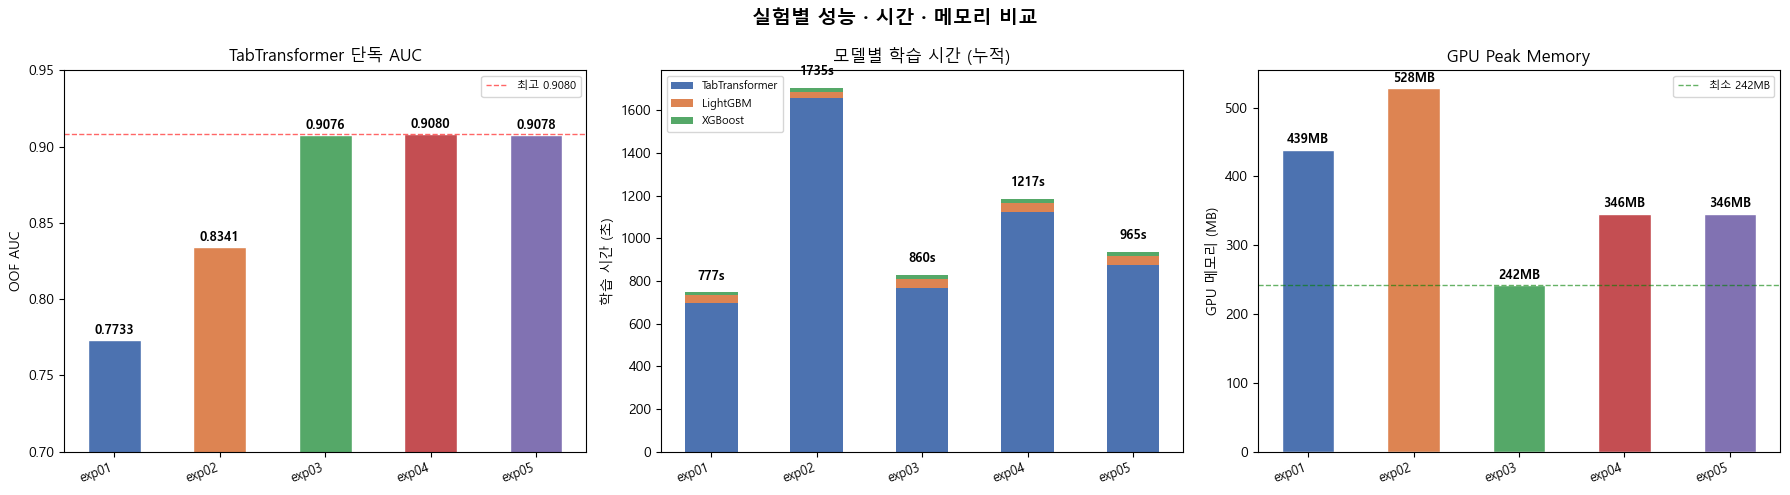

저장 완료: docs/experiment_comparison.png


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

log = pd.read_csv('./experiment_log.csv').dropna(subset=['experiment_name'])
exps = log['experiment_name'].tolist()
x = np.arange(len(exps))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('실험별 성능 · 시간 · 메모리 비교', fontsize=14, fontweight='bold')

# ── 그래프 1: OOF AUC (TT 단독) ──
ax = axes[0]
bars = ax.bar(x, log['oof_tt'], color=colors[:len(exps)], width=0.5, edgecolor='white')
for bar, val in zip(bars, log['oof_tt']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(exps, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.70, 0.95)
ax.set_ylabel('OOF AUC')
ax.set_title('TabTransformer 단독 AUC')
ax.axhline(log['oof_tt'].max(), color='red', linestyle='--', linewidth=1, alpha=0.6,
           label=f'최고 {log["oof_tt"].max():.4f}')
ax.legend(fontsize=8)

# ── 그래프 2: 학습 시간 누적 막대 ──
ax = axes[1]
b1 = ax.bar(x, log['tt_total_s'],  label='TabTransformer', color='#4C72B0', width=0.5)
b2 = ax.bar(x, log['lgb_total_s'], label='LightGBM',       color='#DD8452', width=0.5,
            bottom=log['tt_total_s'])
b3 = ax.bar(x, log['xgb_total_s'], label='XGBoost',        color='#55A868', width=0.5,
            bottom=log['tt_total_s'] + log['lgb_total_s'])
for i, total in enumerate(log['elapsed_s']):
    ax.text(i, total + 15, f'{total:.0f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(exps, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('학습 시간 (초)')
ax.set_title('모델별 학습 시간 (누적)')
ax.legend(fontsize=8, loc='upper left')

# ── 그래프 3: GPU Peak Memory ──
ax = axes[2]
bars = ax.bar(x, log['gpu_peak_mb'], color=colors[:len(exps)], width=0.5, edgecolor='white')
for bar, val in zip(bars, log['gpu_peak_mb']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}MB', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(exps, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('GPU 메모리 (MB)')
ax.set_title('GPU Peak Memory')
ax.axhline(log['gpu_peak_mb'].min(), color='green', linestyle='--', linewidth=1, alpha=0.6,
           label=f'최소 {log["gpu_peak_mb"].min():.0f}MB')
ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs('./docs', exist_ok=True)
plt.savefig('./docs/experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: docs/experiment_comparison.png')